Loading dataset...
Dataset loaded successfully!
Shape: (9357, 15)

Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

First 5 rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,10/03/2004,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,10/03/2004,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,10/03/2004,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,10/03/2004,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794



========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(12), int64(1), object(2)
memory usage: 1.1+ MB
None

========== MISSING VALUES (Before) =====

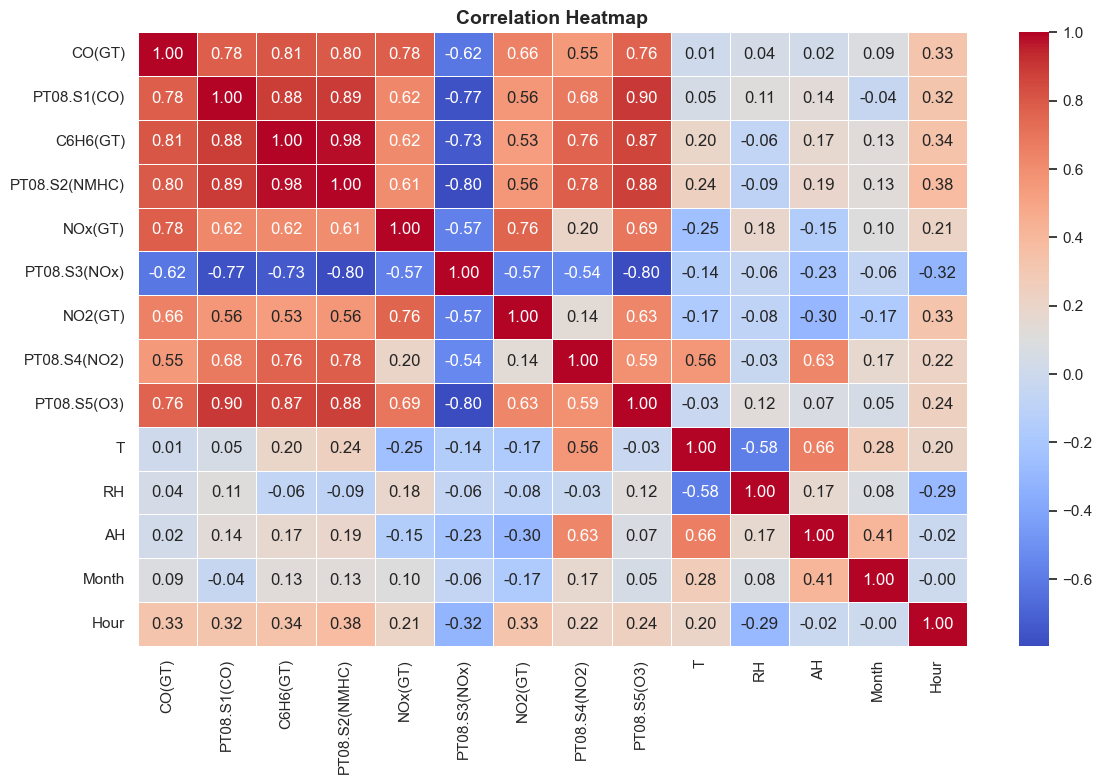

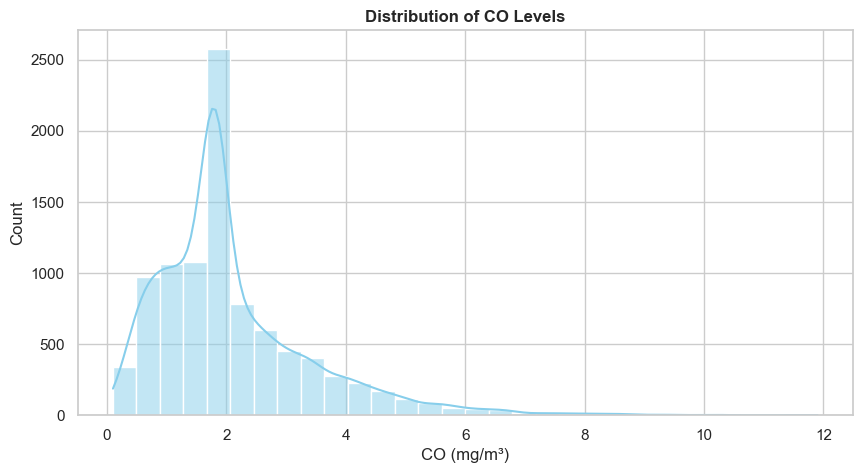

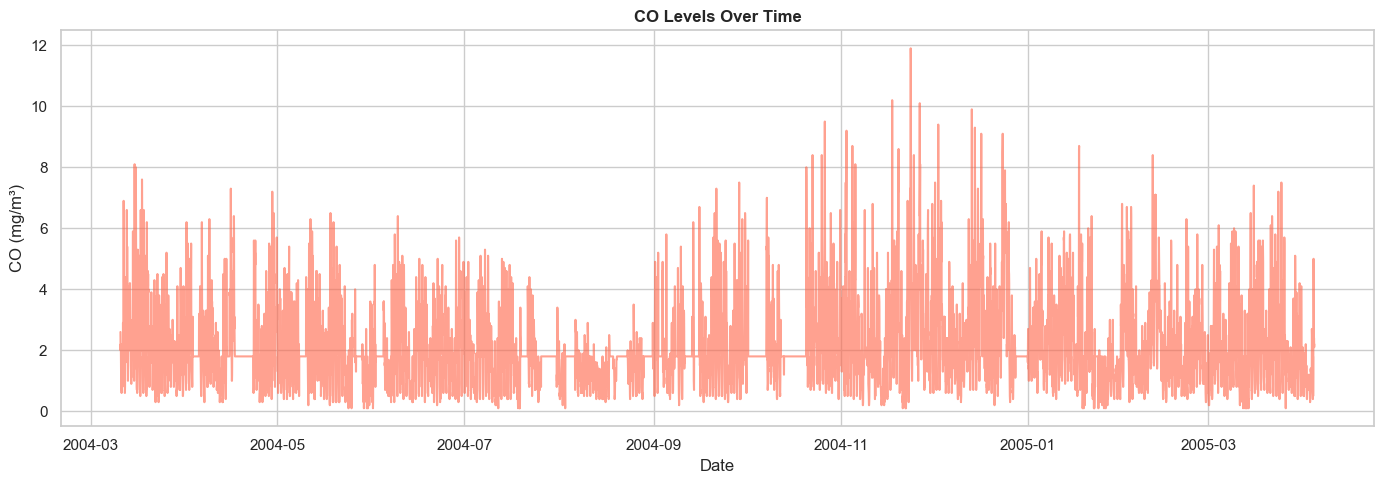

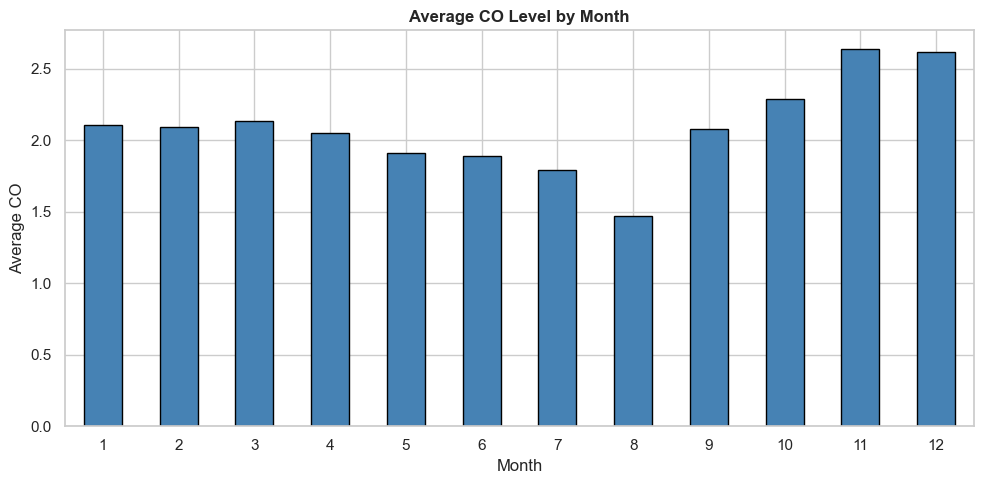

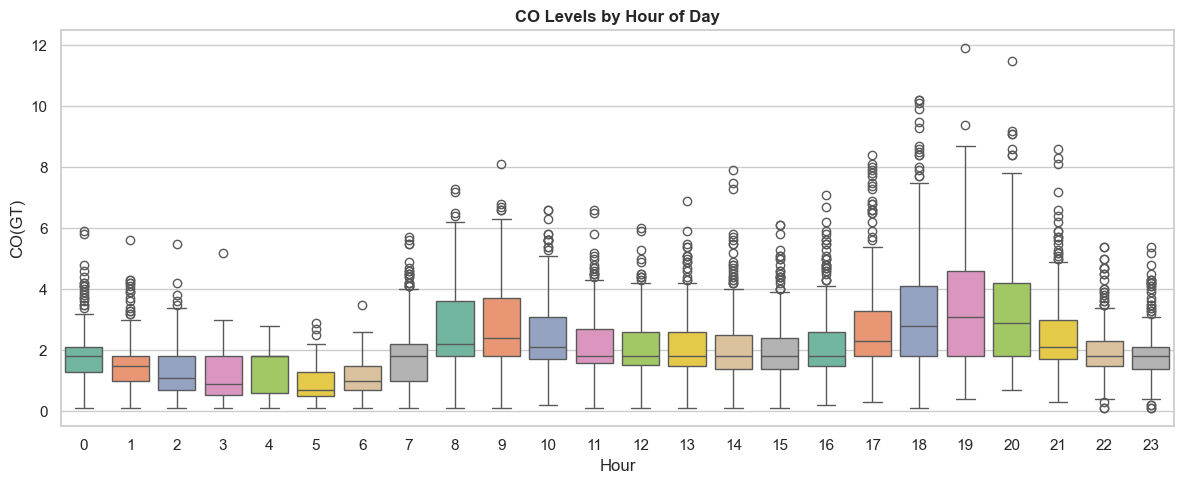

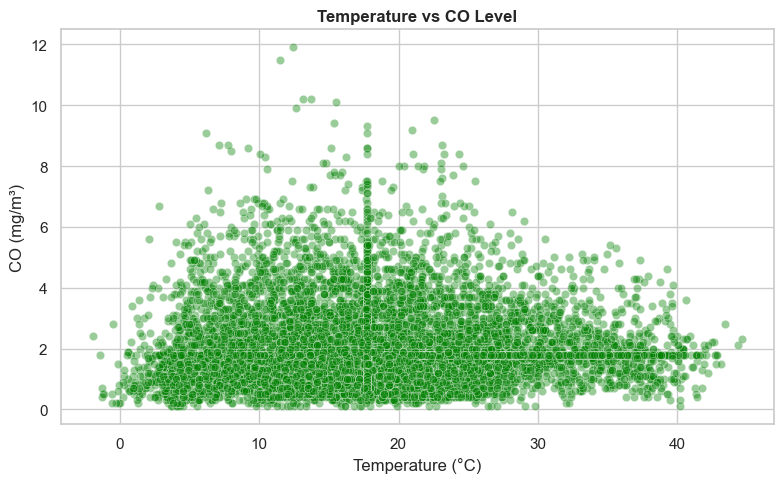


========== KEY INSIGHTS ==========
Average CO Level       : 2.09
Maximum CO Level       : 11.90
Minimum CO Level       : 0.10
Average Temperature    : 18.29 °C
Average Humidity       : 49.24 %

Analysis Completed Successfully!


In [2]:
# ==============================================
# Air Quality Analysis - Fixed Version
# ==============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ----------------------------------------------
# 1. Load Dataset (Important: separator is ';')
# ----------------------------------------------
print("Loading dataset...")

df = pd.read_csv("AirQualityUCI.csv", sep=';')   # ← Most important fix

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

# ----------------------------------------------
# 2. Basic Info
# ----------------------------------------------
print("\n========== DATASET INFO ==========")
print(df.info())

# ----------------------------------------------
# 3. Data Cleaning
# ----------------------------------------------
print("\n========== MISSING VALUES (Before) ==========")
print(df.isnull().sum())

# Replace -200 with NaN (UCI dataset uses -200 as missing)
df.replace(-200, np.nan, inplace=True)

print("\n========== MISSING VALUES (After replacing -200) ==========")
print(df.isnull().sum())

# Drop columns that have too many missing values
df.drop(columns=['NMHC(GT)'], inplace=True, errors='ignore')

# Fill remaining missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\n========== MISSING VALUES (After Cleaning) ==========")
print(df.isnull().sum())

# ----------------------------------------------
# 4. Create DateTime features
# ----------------------------------------------
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')
df['Month'] = df['DateTime'].dt.month
df['Hour'] = df['DateTime'].dt.hour

print("\nDateTime features created!")

# ----------------------------------------------
# 5. Visualizations
# ----------------------------------------------

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. CO Distribution
if 'CO(GT)' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['CO(GT)'], bins=30, kde=True, color='skyblue')
    plt.title("Distribution of CO Levels", fontweight='bold')
    plt.xlabel("CO (mg/m³)")
    plt.show()

# 3. CO over Time
if 'DateTime' in df.columns and 'CO(GT)' in df.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(df['DateTime'], df['CO(GT)'], color='tomato', alpha=0.6)
    plt.title("CO Levels Over Time", fontweight='bold')
    plt.xlabel("Date")
    plt.ylabel("CO (mg/m³)")
    plt.tight_layout()
    plt.show()

# 4. Average CO by Month
if 'Month' in df.columns and 'CO(GT)' in df.columns:
    monthly = df.groupby('Month')['CO(GT)'].mean()
    plt.figure(figsize=(10, 5))
    monthly.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title("Average CO Level by Month", fontweight='bold')
    plt.xlabel("Month")
    plt.ylabel("Average CO")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 5. CO by Hour (Boxplot)
if 'Hour' in df.columns and 'CO(GT)' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.boxplot(x='Hour', y='CO(GT)', data=df, palette="Set2")
    plt.title("CO Levels by Hour of Day", fontweight='bold')
    plt.tight_layout()
    plt.show()

# 6. Temperature vs CO
if 'T' in df.columns and 'CO(GT)' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='T', y='CO(GT)', data=df, alpha=0.4, color='green')
    plt.title("Temperature vs CO Level", fontweight='bold')
    plt.xlabel("Temperature (°C)")
    plt.ylabel("CO (mg/m³)")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------
# 6. Key Insights
# ----------------------------------------------
print("\n========== KEY INSIGHTS ==========")
print(f"Average CO Level       : {df['CO(GT)'].mean():.2f}")
print(f"Maximum CO Level       : {df['CO(GT)'].max():.2f}")
print(f"Minimum CO Level       : {df['CO(GT)'].min():.2f}")
print(f"Average Temperature    : {df['T'].mean():.2f} °C")
print(f"Average Humidity       : {df['RH'].mean():.2f} %")

print("\nAnalysis Completed Successfully!")